<a href="https://colab.research.google.com/github/UmarKhattab09/FareRidePrediction/blob/main/Update_FareRidePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Performed a lot of Data Analysis and Cleaning.
- Ran Different SuperVised Machine Learning Models


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
df = pd.read_csv("cab_rides.csv")
df.head(10)

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL
5,0.44,Lyft,1545071112138,North Station,Haymarket Square,16.5,1.0,f6f6d7e4-3e18-4922-a5f5-181cdd3fa6f2,lyft_lux,Lux Black
6,1.08,Lyft,1543208580200,Northeastern University,Back Bay,10.5,1.0,462816a3-820d-408b-8549-0b39e82f65ac,lyft_plus,Lyft XL
7,1.08,Lyft,1543780384677,Northeastern University,Back Bay,16.5,1.0,474d6376-bc59-4ec9-bf57-4e6d6faeb165,lyft_lux,Lux Black
8,1.08,Lyft,1543818482645,Northeastern University,Back Bay,3.0,1.0,4f9fee41-fde3-4767-bbf1-a00e108701fb,lyft_line,Shared
9,1.08,Lyft,1543315522249,Northeastern University,Back Bay,27.5,1.0,8612d909-98b8-4454-a093-30bd48de0cb3,lyft_luxsuv,Lux Black XL


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  int64  
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  float64
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


In [132]:
df["source"].unique()

array(['Haymarket Square', 'Back Bay', 'North End', 'North Station',
       'Beacon Hill', 'Boston University', 'Fenway', 'South Station',
       'Theatre District', 'West End', 'Financial District',
       'Northeastern University'], dtype=object)

In [90]:
df["destination"].unique()

array(['North Station', 'Northeastern University', 'West End',
       'Haymarket Square', 'South Station', 'Fenway', 'Theatre District',
       'Beacon Hill', 'Back Bay', 'North End', 'Financial District',
       'Boston University'], dtype=object)

In [91]:
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="your_app")
location = geolocator.geocode("Haymarket Square")
print(location.latitude, location.longitude)

37.2149569 -80.4546189


In [92]:
location = geolocator.geocode("North Station")
print(location.latitude, location.longitude)

39.4661332 -0.3777723


In [93]:
!pip install googlemaps

In [133]:
from google.colab import userdata
api_key = userdata.get('MAP_API')


In [95]:
import googlemaps
from datetime import datetime

gmaps = googlemaps.Client(key=api_key)

# Geocoding an address
geocode_result = gmaps.geocode('1600 Amphitheatre Parkway, Mountain View, CA')
# type(geocode_result)
geocode_result[0]['geometry']['location']

{'lat': 37.4219374, 'lng': -122.0929976}

#FIXING Destination and Origin


In [96]:
geocode_result = gmaps.geocode(address="Haymarket Square",components={"administrative_area":"Boston","country":'US'})
geocode_result[0]['geometry']['location']


{'lat': 42.3637994, 'lng': -71.0585053}

In [97]:
geo_code = gmaps.geocode(address="North Station",components={"administrative_area":"Massachusetts","country":'US'})
print(geo_code)

[{'address_components': [{'long_name': 'North Station', 'short_name': 'North Station', 'types': ['establishment', 'light_rail_station', 'point_of_interest', 'subway_station', 'train_station', 'transit_station']}, {'long_name': '135', 'short_name': '135', 'types': ['street_number']}, {'long_name': 'Causeway Street', 'short_name': 'Causeway St', 'types': ['route']}, {'long_name': 'West End', 'short_name': 'West End', 'types': ['neighborhood', 'political']}, {'long_name': 'Boston', 'short_name': 'Boston', 'types': ['locality', 'political']}, {'long_name': 'Suffolk County', 'short_name': 'Suffolk County', 'types': ['administrative_area_level_2', 'political']}, {'long_name': 'Massachusetts', 'short_name': 'MA', 'types': ['administrative_area_level_1', 'political']}, {'long_name': 'United States', 'short_name': 'US', 'types': ['country', 'political']}, {'long_name': '02114', 'short_name': '02114', 'types': ['postal_code']}], 'formatted_address': 'North Station, 135 Causeway St, Boston, MA 02

In [98]:
distance = gmaps.distance_matrix(origins=(42.1450532,-72.48697229999999),destinations=(42.3662621,-71.06111369999999),mode="driving",units = "imperial")
print(distance)

{'destination_addresses': ['North Station, 135 Causeway St, Boston, MA 02114, USA'], 'origin_addresses': ['1686 Boston Rd, Springfield, MA 01129, USA'], 'rows': [{'elements': [{'distance': {'text': '84.3 mi', 'value': 135690}, 'duration': {'text': '1 hour 30 mins', 'value': 5396}, 'status': 'OK'}]}], 'status': 'OK'}


In [99]:
geo_code = gmaps.geocode(address="Back Bay",components={"administrative_area":"Massachusetts","country":'US'})
print(geo_code)

[{'address_components': [{'long_name': 'Back Bay', 'short_name': 'Back Bay', 'types': ['neighborhood', 'political']}, {'long_name': 'Boston', 'short_name': 'Boston', 'types': ['locality', 'political']}, {'long_name': 'Suffolk County', 'short_name': 'Suffolk County', 'types': ['administrative_area_level_2', 'political']}, {'long_name': 'Massachusetts', 'short_name': 'MA', 'types': ['administrative_area_level_1', 'political']}, {'long_name': 'United States', 'short_name': 'US', 'types': ['country', 'political']}], 'formatted_address': 'Back Bay, Boston, MA, USA', 'geometry': {'bounds': {'northeast': {'lat': 42.3569856, 'lng': -71.0698989}, 'southwest': {'lat': 42.3415367, 'lng': -71.09166859999999}}, 'location': {'lat': 42.3495236, 'lng': -71.0794717}, 'location_type': 'APPROXIMATE', 'viewport': {'northeast': {'lat': 42.3569856, 'lng': -71.0698989}, 'southwest': {'lat': 42.3415367, 'lng': -71.09166859999999}}}, 'place_id': 'ChIJsfUV-A5644kRxFubWZLMo7w', 'types': ['neighborhood', 'politic

In [134]:
list_of_destination = df["destination"].unique()
geolocator = Nominatim(user_agent="your_app")
import time
hashmap_location = {}
hashmap_geolocation = {}
for destination in list_of_destination:
  geo_code = gmaps.geocode(address=destination,components={"administrative_area":"Massachusetts","country":'US'})
  # location = geolocator.geocode(destination)
  # print(location.latitude, location.longitude)
  lat = geo_code[0]['geometry']['location']['lat']
  lng = geo_code[0]['geometry']['location']['lng']
  correct_address = geo_code[0]["formatted_address"]
  # df.loc[df["destination"] == destination, "destination"] = correct_address
  hashmap_location[destination] = (lat,lng)
  hashmap_geolocation[destination] = correct_address
  time.sleep(2)



In [136]:
# hashmap_location
# hashmap_geolocation

# hashmap_location = {'North Station': (42.3662621, -71.06111369999999),
#  'Northeastern University': (42.3398067, -71.0891717),
#  'West End': (42.3651729, -71.0641373),
#  'Haymarket Square': (42.1450532, -72.48697229999999),
#  'South Station': (42.3486455, -71.0586892),
#  'Fenway': (42.346832, -71.0923139),
#  'Theatre District': (42.3518662, -71.0642623),
#  'Beacon Hill': (42.3561948, -71.06939),
#  'Back Bay': (42.3495236, -71.0794717),
#  'North End': (42.3652089, -71.0554946),
#  'Financial District': (42.3559219, -71.05497679999999),
#  'Boston University': (42.3504997, -71.1053991)}
# hashmap_geolocation = {'North Station': 'North Station, 135 Causeway St, Boston, MA 02114, USA',
#  'Northeastern University': '360 Huntington Ave, Boston, MA 02115, USA',
#  'West End': 'West End, Boston, MA, USA',
#  'Haymarket Square': '1686 Boston Rd, Springfield, MA 01129, USA',
#  'South Station': 'S Station, Boston, MA, USA',
#  'Fenway': 'Fenway–Kenmore, Boston, MA, USA',
#  'Theatre District': 'Boston Theater District, Boston, MA, USA',
#  'Beacon Hill': 'Beacon Hill, Boston, MA, USA',
#  'Back Bay': 'Back Bay, Boston, MA, USA',
#  'North End': 'North End, Boston, MA, USA',
#  'Financial District': 'Financial District, Boston, MA, USA',
#  'Boston University': 'Commonwealth Ave, Boston, MA 02215, USA'}

{'North Station': 'North Station, 135 Causeway St, Boston, MA 02114, USA',
 'Northeastern University': '360 Huntington Ave, Boston, MA 02115, USA',
 'West End': 'West End, Boston, MA, USA',
 'Haymarket Square': '1686 Boston Rd, Springfield, MA 01129, USA',
 'South Station': 'S Station, Boston, MA, USA',
 'Fenway': 'Fenway–Kenmore, Boston, MA, USA',
 'Theatre District': 'Boston Theater District, Boston, MA, USA',
 'Beacon Hill': 'Beacon Hill, Boston, MA, USA',
 'Back Bay': 'Back Bay, Boston, MA, USA',
 'North End': 'North End, Boston, MA, USA',
 'Financial District': 'Financial District, Boston, MA, USA',
 'Boston University': 'Commonwealth Ave, Boston, MA 02215, USA'}

In [137]:
df["Formated_Address_Destination"] = df["destination"].map(hashmap_geolocation)
df["Formated_Address_Source"]  = df["source"].map(hashmap_geolocation)
df["LatLong_Destination"] = df["destination"].map(hashmap_location)
df["LatLong_Source"] = df["source"].map(hashmap_location)

In [138]:
df["Fixed_TimeStamps"] = pd.to_datetime(df["time_stamp"]/1000,unit="s")
df

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,Formated_Address_Destination,Formated_Address_Source,LatLong_Destination,LatLong_Source,Fixed_TimeStamps
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-12-16 09:30:07.890000105
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-27 02:00:23.677000046
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-28 01:00:22.197999954
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-30 04:53:02.749000072
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-29 03:49:20.223000050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693066,1.00,Uber,1543708385534,North End,West End,13.0,1.0,616d3611-1820-450a-9845-a9ff304a4842,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,"North End, Boston, MA, USA","West End, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3651729, -71.0641373)",2018-12-01 23:53:05.533999919
693067,1.00,Uber,1543708385534,North End,West End,9.5,1.0,633a3fc3-1f86-4b9e-9d48-2b7132112341,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX,"North End, Boston, MA, USA","West End, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3651729, -71.0641373)",2018-12-01 23:53:05.533999919
693068,1.00,Uber,1543708385534,North End,West End,NaN,1.0,64d451d0-639f-47a4-9b7c-6fd92fbd264f,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,"North End, Boston, MA, USA","West End, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3651729, -71.0641373)",2018-12-01 23:53:05.533999919
693069,1.00,Uber,1543708385534,North End,West End,27.0,1.0,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV,"North End, Boston, MA, USA","West End, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3651729, -71.0641373)",2018-12-01 23:53:05.533999919


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 15 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   distance                      693071 non-null  float64       
 1   cab_type                      693071 non-null  object        
 2   time_stamp                    693071 non-null  int64         
 3   destination                   693071 non-null  object        
 4   source                        693071 non-null  object        
 5   price                         637976 non-null  float64       
 6   surge_multiplier              693071 non-null  float64       
 7   id                            693071 non-null  object        
 8   product_id                    693071 non-null  object        
 9   name                          693071 non-null  object        
 10  Formated_Address_Destination  693071 non-null  object        
 11  Formated_Addr

In [140]:
# df.isna().sum()
df[df["price"].isna()]

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,Formated_Address_Destination,Formated_Address_Source,LatLong_Destination,LatLong_Source,Fixed_TimeStamps
18,1.11,Uber,1543673584211,West End,North End,NaN,1.0,fa5fb705-03a0-4eb9-82d9-7fe80872f754,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,"West End, Boston, MA, USA","North End, Boston, MA, USA","(42.3651729, -71.0641373)","(42.3652089, -71.0554946)",2018-12-01 14:13:04.210999966
31,2.48,Uber,1543794776318,South Station,Beacon Hill,NaN,1.0,eee70d94-6706-4b95-a8ce-0e34f0fa8f37,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,"S Station, Boston, MA, USA","Beacon Hill, Boston, MA, USA","(42.3486455, -71.0586892)","(42.3561948, -71.06939)",2018-12-02 23:52:56.318000078
40,2.94,Uber,1543523885298,Fenway,North Station,NaN,1.0,7f47ff53-7cf2-4a6a-8049-83c90e042593,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,"Fenway–Kenmore, Boston, MA, USA","North Station, 135 Causeway St, Boston, MA 021...","(42.346832, -71.0923139)","(42.3662621, -71.06111369999999)",2018-11-29 20:38:05.298000097
60,1.16,Uber,1544731816318,West End,North End,NaN,1.0,43abdbe4-ab9e-4f39-afdc-31cfa375dc25,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,"West End, Boston, MA, USA","North End, Boston, MA, USA","(42.3651729, -71.0641373)","(42.3652089, -71.0554946)",2018-12-13 20:10:16.318000078
69,2.67,Uber,1543583283653,Beacon Hill,North End,NaN,1.0,80db1c49-9d51-4575-a4f4-1ec23b4d3e31,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,"Beacon Hill, Boston, MA, USA","North End, Boston, MA, USA","(42.3561948, -71.06939)","(42.3652089, -71.0554946)",2018-11-30 13:08:03.653000116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693025,2.50,Uber,1544886913192,Beacon Hill,South Station,NaN,1.0,70ad9983-92dd-4cdf-af16-732e7e9ee9d0,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,"Beacon Hill, Boston, MA, USA","S Station, Boston, MA, USA","(42.3561948, -71.06939)","(42.3486455, -71.0586892)",2018-12-15 15:15:13.191999912
693047,0.91,Uber,1543456028123,Beacon Hill,Haymarket Square,NaN,1.0,84e05ef0-781a-4bd5-a593-bbbf659d4ba0,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,"Beacon Hill, Boston, MA, USA","1686 Boston Rd, Springfield, MA 01129, USA","(42.3561948, -71.06939)","(42.1450532, -72.48697229999999)",2018-11-29 01:47:08.122999907
693049,1.79,Uber,1543456028123,Beacon Hill,North End,NaN,1.0,885ef635-299e-45cf-8052-c45a39e9822a,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,"Beacon Hill, Boston, MA, USA","North End, Boston, MA, USA","(42.3561948, -71.06939)","(42.3652089, -71.0554946)",2018-11-29 01:47:08.122999907
693060,1.61,Uber,1543728484149,Haymarket Square,Theatre District,NaN,1.0,50a7b6be-ed2a-4a11-8d36-73bd977ad66a,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,"1686 Boston Rd, Springfield, MA 01129, USA","Boston Theater District, Boston, MA, USA","(42.1450532, -72.48697229999999)","(42.3518662, -71.0642623)",2018-12-02 05:28:04.148999929


In [141]:
df.drop(columns= ["time_stamp","destination","source","id"],inplace=True)

In [142]:
# df['product_id'] #PRODUCT ID CONTAINS SOME NUMBERS
df[df["product_id"].str.contains(r'\d',regex=True)]["product_id"]

,product_id
12,6f72dfc5-27f1-42e8-84db-ccc7a75f6969
13,6c84fd89-3f11-4782-9b50-97c468b19529
14,55c66225-fbe7-4fd5-9072-eab1ece5e23e
15,9a0e7b09-b92b-4c41-9779-2ad22b4d779d
16,6d318bcc-22a3-4af6-bddd-b409bfce1546
...,...
693066,6f72dfc5-27f1-42e8-84db-ccc7a75f6969
693067,55c66225-fbe7-4fd5-9072-eab1ece5e23e
693068,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a
693069,6d318bcc-22a3-4af6-bddd-b409bfce1546


#Conclusion
- The Feature Column **price** has a lot of missing values
- The feature column **product_id** is also have values that do not make sense.

- What I can do right now is drop the price column as we need price for our model training, and check if there is any missng product id


In [143]:
df.dropna(inplace=True)
df[df["product_id"].str.contains(r'\d',regex=True)]["product_id"]

,product_id
12,6f72dfc5-27f1-42e8-84db-ccc7a75f6969
13,6c84fd89-3f11-4782-9b50-97c468b19529
14,55c66225-fbe7-4fd5-9072-eab1ece5e23e
15,9a0e7b09-b92b-4c41-9779-2ad22b4d779d
16,6d318bcc-22a3-4af6-bddd-b409bfce1546
...,...
693065,9a0e7b09-b92b-4c41-9779-2ad22b4d779d
693066,6f72dfc5-27f1-42e8-84db-ccc7a75f6969
693067,55c66225-fbe7-4fd5-9072-eab1ece5e23e
693069,6d318bcc-22a3-4af6-bddd-b409bfce1546


In [144]:
df[df["name"].str.contains(r'\d',regex=True)]

,distance,cab_type,price,surge_multiplier,product_id,name,Formated_Address_Destination,Formated_Address_Source,LatLong_Destination,LatLong_Source,Fixed_TimeStamps


In [145]:
df["product_id"].unique()

array(['lyft_line', 'lyft_premier', 'lyft', 'lyft_luxsuv', 'lyft_plus',
       'lyft_lux', '6f72dfc5-27f1-42e8-84db-ccc7a75f6969',
       '6c84fd89-3f11-4782-9b50-97c468b19529',
       '55c66225-fbe7-4fd5-9072-eab1ece5e23e',
       '9a0e7b09-b92b-4c41-9779-2ad22b4d779d',
       '6d318bcc-22a3-4af6-bddd-b409bfce1546',
       '997acbb5-e102-41e1-b155-9df7de0a73f2'], dtype=object)

In [146]:
df["name"].unique()

array(['Shared', 'Lux', 'Lyft', 'Lux Black XL', 'Lyft XL', 'Lux Black',
       'UberXL', 'Black', 'UberX', 'WAV', 'Black SUV', 'UberPool'],
      dtype=object)

In [147]:
df[df["name"]=="Shared"]["product_id"].unique()

array(['lyft_line'], dtype=object)

In [148]:
df[df["name"]=="Lux"]["product_id"].unique()

array(['lyft_premier'], dtype=object)

In [149]:
for unique in df["name"].unique():
  print(df[df["name"]==unique]["product_id"].unique(), f"for {unique}")

['lyft_line'] for Shared
['lyft_premier'] for Lux
['lyft'] for Lyft
['lyft_luxsuv'] for Lux Black XL
['lyft_plus'] for Lyft XL
['lyft_lux'] for Lux Black
['6f72dfc5-27f1-42e8-84db-ccc7a75f6969'] for UberXL
['6c84fd89-3f11-4782-9b50-97c468b19529'] for Black
['55c66225-fbe7-4fd5-9072-eab1ece5e23e'] for UberX
['9a0e7b09-b92b-4c41-9779-2ad22b4d779d'] for WAV
['6d318bcc-22a3-4af6-bddd-b409bfce1546'] for Black SUV
['997acbb5-e102-41e1-b155-9df7de0a73f2'] for UberPool


In [150]:
df[df["product_id"]=="6f72dfc5-27f1-42e8-84db-ccc7a75f6969"]["name"].unique()

array(['UberXL'], dtype=object)

In [151]:
df[df["product_id"].str.contains(r'\d',regex=True)]["name"].unique()

array(['UberXL', 'Black', 'UberX', 'WAV', 'Black SUV', 'UberPool'],
      dtype=object)

#Update
- Dropping the price column didn't effect ProductID problem
- What I am thinking is we can let go of the product_id during training as it doesnt make sense.

- What I am trying to achieve is that when a user uploads his location, it will calculate the distance that I need to implement and its gonna provide be calculating surge and provide prices based on all the unique names



In [207]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 637976 entries, 0 to 693070
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   distance                      637976 non-null  float64       
 1   cab_type                      637976 non-null  object        
 2   price                         637976 non-null  float64       
 3   surge_multiplier              637976 non-null  float64       
 4   product_id                    637976 non-null  object        
 5   name                          637976 non-null  object        
 6   Formated_Address_Destination  637976 non-null  object        
 7   Formated_Address_Source       637976 non-null  object        
 8   LatLong_Destination           637976 non-null  object        
 9   LatLong_Source                637976 non-null  object        
 10  Fixed_TimeStamps              637976 non-null  datetime64[ns]
 11  hour              

In [153]:
df["distance"].describe()

,distance
count,637976.000000
mean,2.189261
std,1.135413
min,0.020000
25%,1.270000
50%,2.160000
75%,2.930000
max,7.860000


In [154]:
df.describe()

,distance,price,surge_multiplier,Fixed_TimeStamps
count,637976.000000,637976.000000,637976.000000,637976
mean,2.189261,16.545125,1.015068,2018-12-05 21:34:05.413373184
min,0.020000,2.500000,1.000000,2018-11-26 03:40:46.318000078
25%,1.270000,9.000000,1.000000,2018-11-28 22:26:08.211000064
50%,2.160000,13.500000,1.000000,2018-12-02 07:52:59.568000
75%,2.930000,22.500000,1.000000,2018-12-14 22:45:04.677999872
max,7.860000,97.500000,3.000000,2018-12-18 19:15:10.943000078
std,1.135413,9.324359,0.095422,NaN


In [169]:
df[(df["price"] < 2.6) & (df["distance"] == 1.53)]

,distance,cab_type,price,surge_multiplier,product_id,name,Formated_Address_Destination,Formated_Address_Source,LatLong_Destination,LatLong_Source,Fixed_TimeStamps
5901,1.53,Lyft,2.5,1.0,lyft_line,Shared,"Back Bay, Boston, MA, USA","Commonwealth Ave, Boston, MA 02215, USA","(42.3495236, -71.0794717)","(42.3504997, -71.1053991)",2018-11-28 23:33:41.778000116
36008,1.53,Lyft,2.5,1.0,lyft_line,Shared,"Back Bay, Boston, MA, USA","Fenway–Kenmore, Boston, MA, USA","(42.3495236, -71.0794717)","(42.346832, -71.0923139)",2018-12-18 03:10:08.510999918


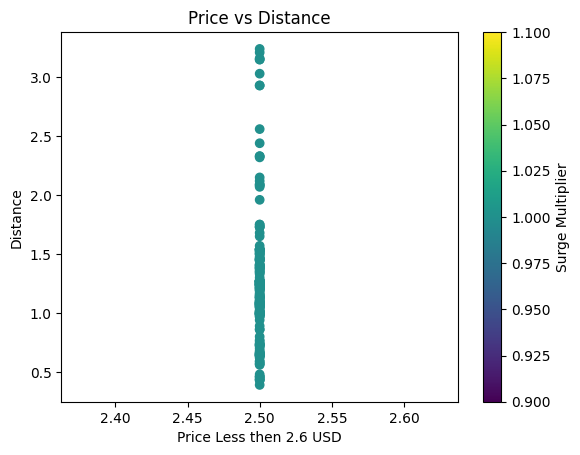

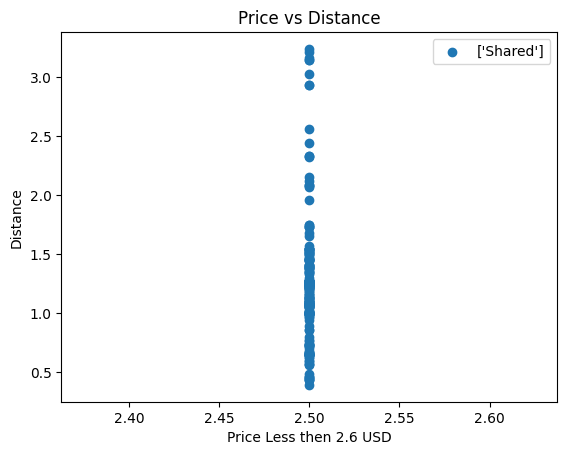

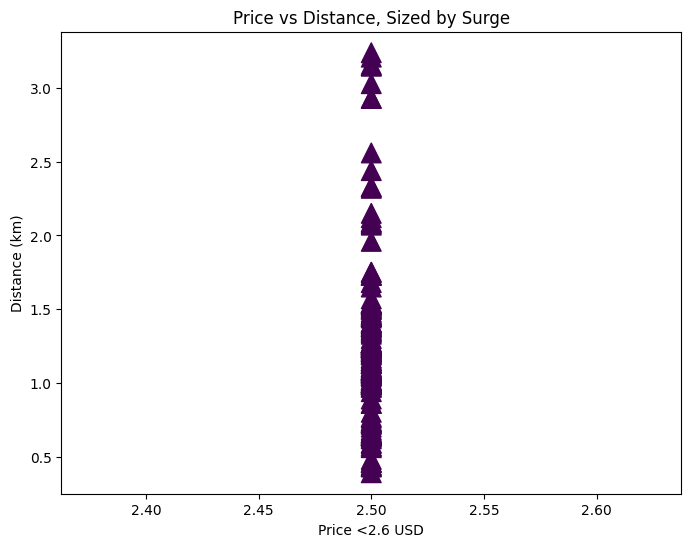

In [208]:
import seaborn as sns
import matplotlib.pyplot as plt
filtered_df = df[df["price"] < 2.6] # Changed to 2.6 based on previous cell to include all low prices
plt.scatter(filtered_df["price"], filtered_df["distance"],c=filtered_df["surge_multiplier"])
plt.title("Price vs Distance")
plt.colorbar(label="Surge Multiplier")
plt.xlabel("Price Less then 2.6 USD")
plt.ylabel("Distance")
plt.show()

filtered_df = df[df["price"] < 2.6] # Changed to 2.6 based on previous cell to include all low prices
plt.scatter(filtered_df["price"], filtered_df["distance"],label=filtered_df["name"].unique())
plt.title("Price vs Distance")
# plt.colorbar(label="Surge Multiplier")
plt.xlabel("Price Less then 2.6 USD")
plt.ylabel("Distance")
plt.legend()
plt.show()

#Surge By Size
plt.figure(figsize=(8,6))
sizes = filtered_df['surge_multiplier'] * 200  # Scale 20-200
plt.scatter(filtered_df["price"], filtered_df["distance"],
            s=sizes, marker='^', c = filtered_df['surge_multiplier'])
plt.xlabel("Price <2.6 USD")
plt.colorbar
plt.ylabel("Distance (km)")
plt.title("Price vs Distance, Sized by Surge")
plt.show()


In [209]:
filtered_df

,distance,cab_type,price,surge_multiplier,product_id,name,Formated_Address_Destination,Formated_Address_Source,LatLong_Destination,LatLong_Source,Fixed_TimeStamps,hour
5901,1.53,Lyft,2.5,1.0,lyft_line,Shared,"Back Bay, Boston, MA, USA","Commonwealth Ave, Boston, MA 02215, USA","(42.3495236, -71.0794717)","(42.3504997, -71.1053991)",2018-11-28 23:33:41.778000116,23
7370,1.39,Lyft,2.5,1.0,lyft_line,Shared,"Beacon Hill, Boston, MA, USA","1686 Boston Rd, Springfield, MA 01129, USA","(42.3561948, -71.06939)","(42.1450532, -72.48697229999999)",2018-12-18 11:45:10.302999973,11
8623,0.65,Lyft,2.5,1.0,lyft_line,Shared,"Financial District, Boston, MA, USA","S Station, Boston, MA, USA","(42.3559219, -71.05497679999999)","(42.3486455, -71.0586892)",2018-11-28 21:20:10.174000025,21
16675,1.47,Lyft,2.5,1.0,lyft_line,Shared,"Back Bay, Boston, MA, USA","Fenway–Kenmore, Boston, MA, USA","(42.3495236, -71.0794717)","(42.346832, -71.0923139)",2018-11-27 06:06:21.923000097,6
17032,0.98,Lyft,2.5,1.0,lyft_line,Shared,"North Station, 135 Causeway St, Boston, MA 021...","North End, Boston, MA, USA","(42.3662621, -71.06111369999999)","(42.3652089, -71.0554946)",2018-11-29 02:29:08.099999905,2
...,...,...,...,...,...,...,...,...,...,...,...,...
677015,0.99,Lyft,2.5,1.0,lyft_line,Shared,"Financial District, Boston, MA, USA","1686 Boston Rd, Springfield, MA 01129, USA","(42.3559219, -71.05497679999999)","(42.1450532, -72.48697229999999)",2018-12-18 06:40:13.953000069,6
679085,0.66,Lyft,2.5,1.0,lyft_line,Shared,"S Station, Boston, MA, USA","Boston Theater District, Boston, MA, USA","(42.3486455, -71.0586892)","(42.3518662, -71.0642623)",2018-12-03 07:38:01.966000080,7
679217,1.33,Lyft,2.5,1.0,lyft_line,Shared,"S Station, Boston, MA, USA","Back Bay, Boston, MA, USA","(42.3486455, -71.0586892)","(42.3495236, -71.0794717)",2018-11-27 20:27:22.132999897,20
679502,1.54,Lyft,2.5,1.0,lyft_line,Shared,"S Station, Boston, MA, USA","Beacon Hill, Boston, MA, USA","(42.3486455, -71.0586892)","(42.3561948, -71.06939)",2018-11-27 03:36:22.115000010,3


In [210]:
df['hour'] = df['Fixed_TimeStamps'].dt.hour
filtered_df["hour"] = filtered_df["Fixed_TimeStamps"].dt.hour

/tmp/ipython-input-104486219.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["hour"] = filtered_df["Fixed_TimeStamps"].dt.hour


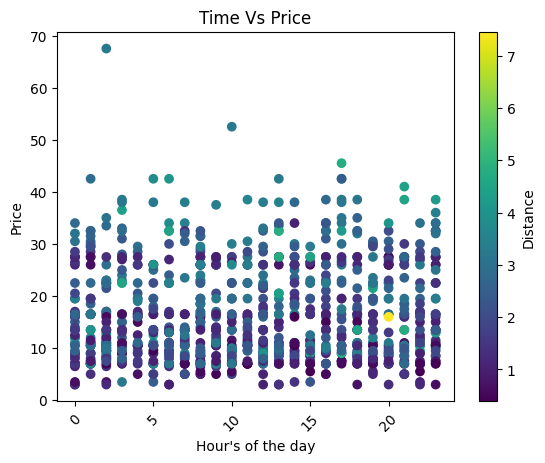

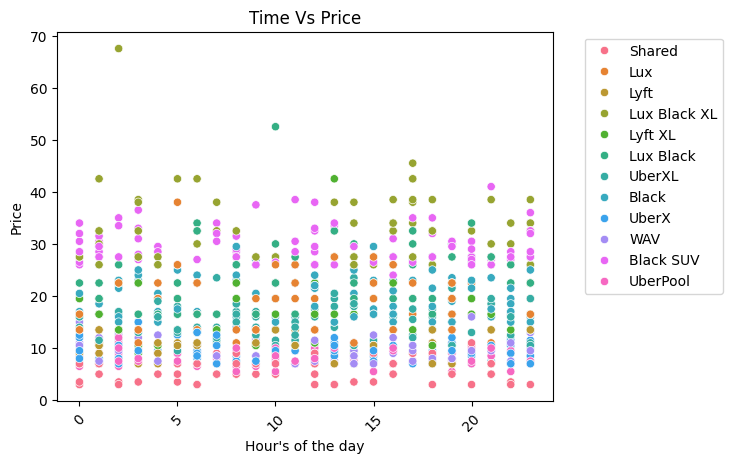

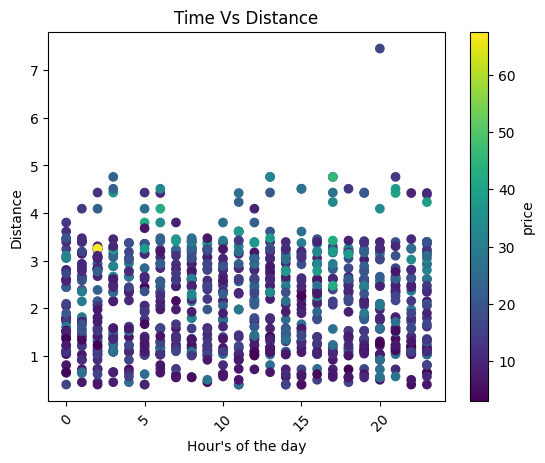

In [211]:

# filtered_df = df[df["price"] < 2.6] # Changed to 2.6 based on previous cell to include all low prices
plt.scatter(df["hour"].iloc[:1000], df["price"].iloc[:1000],c=df["distance"].iloc[:1000])
plt.title("Time Vs Price")
plt.colorbar(label="Distance")
plt.xlabel("Hour's of the day")
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.show()

sns.scatterplot(data=df.iloc[:1000], x="hour", y="price", hue="name")
plt.title("Time Vs Price")
# plt.colorbar(label="Distance") # Colorbar is not suitable when hue is categorical
plt.xlabel("Hour's of the day")
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.show()

# filtered_df = df[df["price"] < 2.6] # Changed to 2.6 based on previous cell to include all low prices
plt.scatter(df["hour"].iloc[:1000], df["distance"].iloc[:1000],c=df["price"].iloc[:1000])
plt.title("Time Vs Distance")
plt.colorbar(label="price")
plt.xlabel("Hour's of the day")
plt.xticks(rotation=45)
plt.ylabel("Distance")
plt.show()

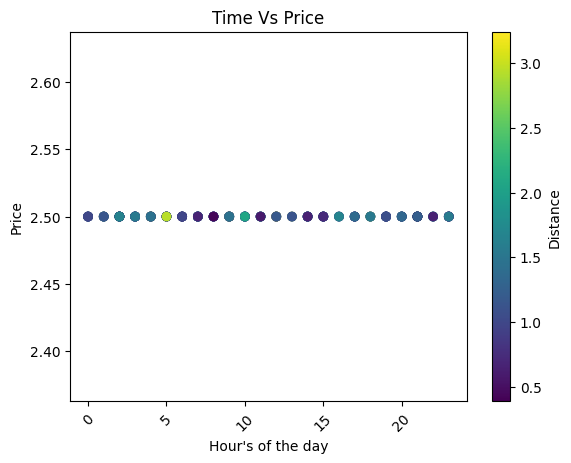

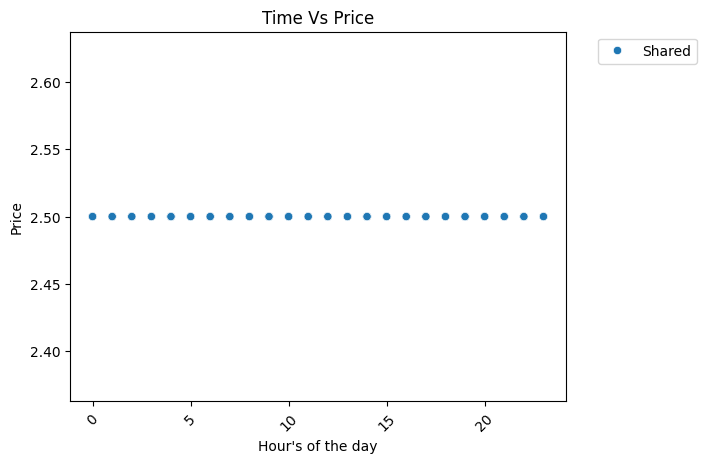

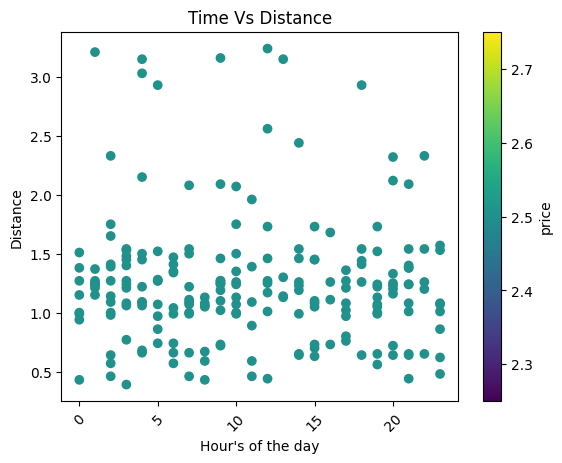

In [219]:

filtered_df = df[df["price"] < 2.6] # Changed to 2.6 based on previous cell to include all low prices
plt.scatter(filtered_df["hour"].iloc[:1000], filtered_df["price"].iloc[:1000],c=filtered_df["distance"].iloc[:1000])
plt.title("Time Vs Price")
plt.colorbar(label="Distance")
plt.xlabel("Hour's of the day")
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.show()

sns.scatterplot(data=filtered_df.iloc[:1000], x="hour", y="price", hue="name")
plt.title("Time Vs Price")
# plt.colorbar(label="Distance") # Colorbar is not suitable when hue is categorical
plt.xlabel("Hour's of the day")
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.show()

# filtered_df = df[df["price"] < 2.6] # Changed to 2.6 based on previous cell to include all low prices
plt.scatter(filtered_df["hour"].iloc[:1000], filtered_df["distance"].iloc[:1000],c=filtered_df["price"].iloc[:1000])
plt.title("Time Vs Distance")
plt.colorbar(label="price")
plt.xlabel("Hour's of the day")
plt.xticks(rotation=45)
plt.ylabel("Distance")
plt.show()

In [220]:
filtered_df

,distance,cab_type,price,surge_multiplier,product_id,name,Formated_Address_Destination,Formated_Address_Source,LatLong_Destination,LatLong_Source,Fixed_TimeStamps,hour
5901,1.53,Lyft,2.5,1.0,lyft_line,Shared,"Back Bay, Boston, MA, USA","Commonwealth Ave, Boston, MA 02215, USA","(42.3495236, -71.0794717)","(42.3504997, -71.1053991)",2018-11-28 23:33:41.778000116,23
7370,1.39,Lyft,2.5,1.0,lyft_line,Shared,"Beacon Hill, Boston, MA, USA","1686 Boston Rd, Springfield, MA 01129, USA","(42.3561948, -71.06939)","(42.1450532, -72.48697229999999)",2018-12-18 11:45:10.302999973,11
8623,0.65,Lyft,2.5,1.0,lyft_line,Shared,"Financial District, Boston, MA, USA","S Station, Boston, MA, USA","(42.3559219, -71.05497679999999)","(42.3486455, -71.0586892)",2018-11-28 21:20:10.174000025,21
16675,1.47,Lyft,2.5,1.0,lyft_line,Shared,"Back Bay, Boston, MA, USA","Fenway–Kenmore, Boston, MA, USA","(42.3495236, -71.0794717)","(42.346832, -71.0923139)",2018-11-27 06:06:21.923000097,6
17032,0.98,Lyft,2.5,1.0,lyft_line,Shared,"North Station, 135 Causeway St, Boston, MA 021...","North End, Boston, MA, USA","(42.3662621, -71.06111369999999)","(42.3652089, -71.0554946)",2018-11-29 02:29:08.099999905,2
...,...,...,...,...,...,...,...,...,...,...,...,...
677015,0.99,Lyft,2.5,1.0,lyft_line,Shared,"Financial District, Boston, MA, USA","1686 Boston Rd, Springfield, MA 01129, USA","(42.3559219, -71.05497679999999)","(42.1450532, -72.48697229999999)",2018-12-18 06:40:13.953000069,6
679085,0.66,Lyft,2.5,1.0,lyft_line,Shared,"S Station, Boston, MA, USA","Boston Theater District, Boston, MA, USA","(42.3486455, -71.0586892)","(42.3518662, -71.0642623)",2018-12-03 07:38:01.966000080,7
679217,1.33,Lyft,2.5,1.0,lyft_line,Shared,"S Station, Boston, MA, USA","Back Bay, Boston, MA, USA","(42.3486455, -71.0586892)","(42.3495236, -71.0794717)",2018-11-27 20:27:22.132999897,20
679502,1.54,Lyft,2.5,1.0,lyft_line,Shared,"S Station, Boston, MA, USA","Beacon Hill, Boston, MA, USA","(42.3486455, -71.0586892)","(42.3561948, -71.06939)",2018-11-27 03:36:22.115000010,3


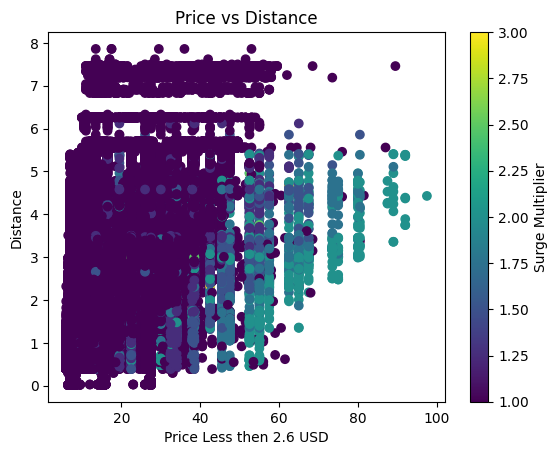

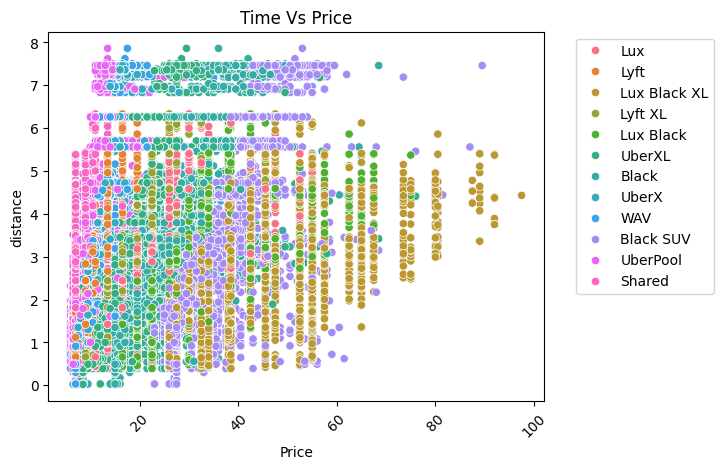

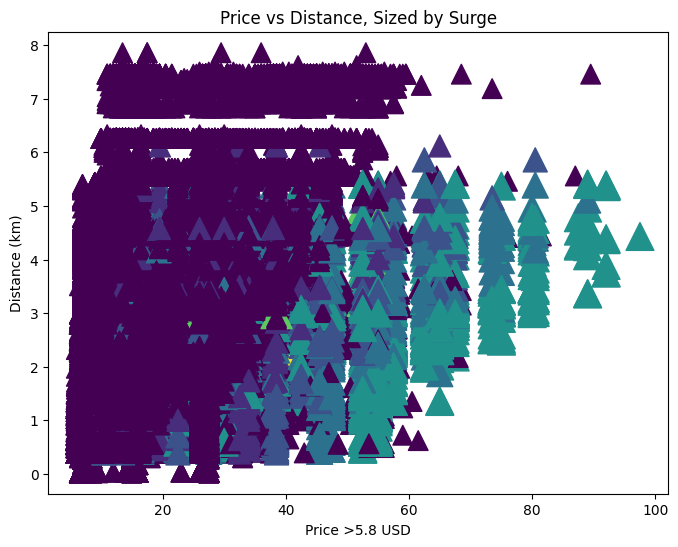

In [267]:
import seaborn as sns
import matplotlib.pyplot as plt
filtered_df = df[df["price"] > 5.6] # Changed to 2.6 based on previous cell to include all low prices
plt.scatter(filtered_df["price"], filtered_df["distance"],c=filtered_df["surge_multiplier"])
plt.title("Price vs Distance")
plt.colorbar(label="Surge Multiplier")
plt.xlabel("Price Less then 2.6 USD")
plt.ylabel("Distance")
plt.show()

sns.scatterplot(data=filtered_df, x="price", y="distance", hue="name")
plt.title("Time Vs Price")
# plt.colorbar(label="Distance") # Colorbar is not suitable when hue is categorical
plt.xlabel("Price")
plt.xticks(rotation=45)
plt.ylabel("distance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.show()

#Surge By Size
plt.figure(figsize=(8,6))
sizes = filtered_df['surge_multiplier'] * 200  # Scale 20-200
plt.scatter(filtered_df["price"], filtered_df["distance"],
            s=sizes, marker='^', c = filtered_df['surge_multiplier'])
plt.xlabel("Price >5.8 USD")
plt.colorbar
plt.ylabel("Distance (km)")
plt.title("Price vs Distance, Sized by Surge")
plt.show()


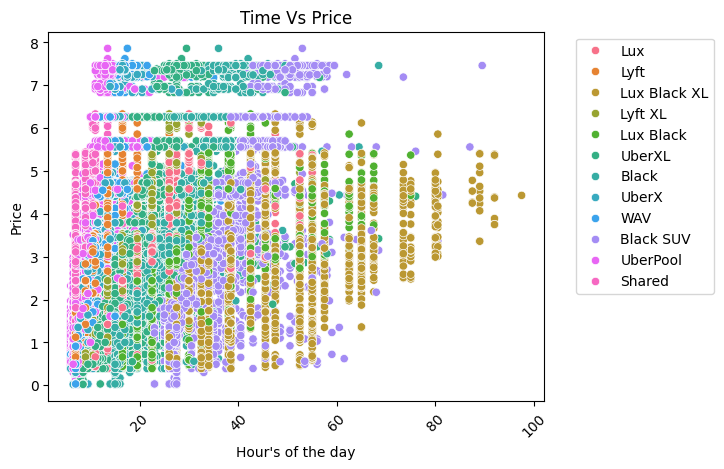
# Graphs Conclusion
What I know, that you can not have same price while having the distance increasing.
- If distance increases, price increases. no matter the surge charge.
- I thought it was outliers but I realized that it can be because they are using different ride apps. However 2.5 USD shows that shared rides upto a certain distance have is cheap.

Moreover, price roughly stay same but depending on the ride service type, it increases. However, Let me remove try the boxplot to remove the outliers it is showing and take a closer look


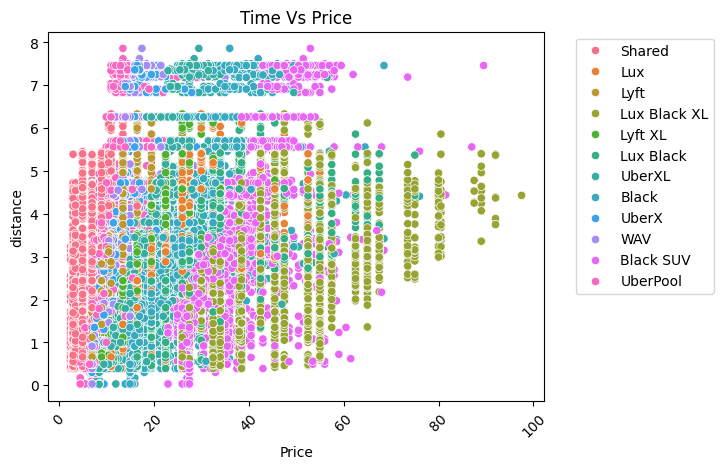

In [268]:
sns.scatterplot(data=df, x="price", y="distance", hue="name")
plt.title("Time Vs Price")

plt.xlabel("Price")
plt.xticks(rotation=45)
plt.ylabel("distance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.show()


<Axes: ylabel='distance'>

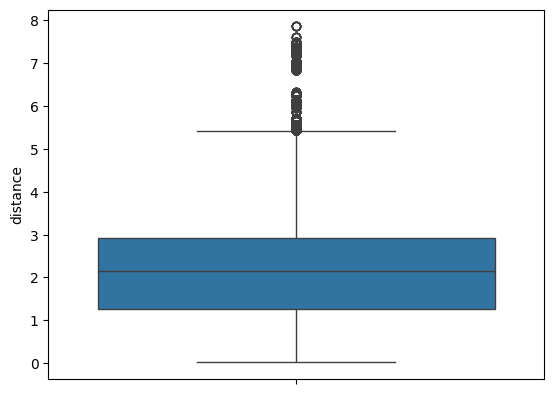

In [247]:
sns.boxplot(df["distance"])

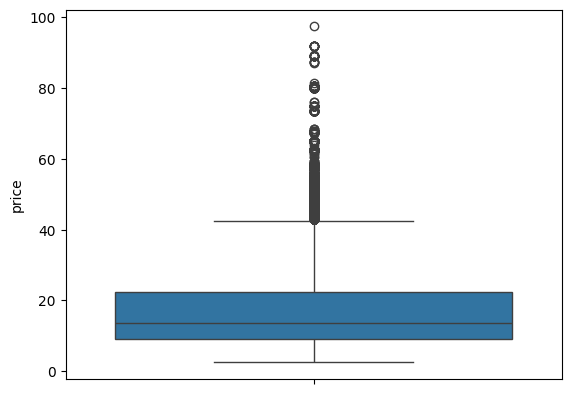

In [248]:
x = sns.boxplot(df["price"])

#REMOVIG PRICE OUTLIERS


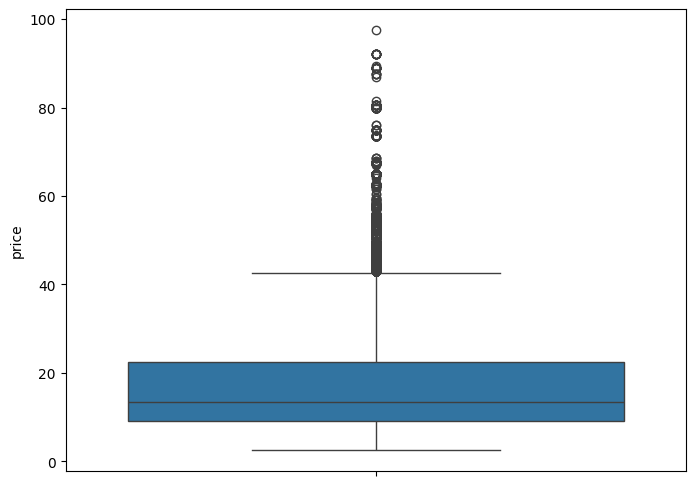

Total: 637976, Outliers: 5589 (99.1%)


In [258]:
from matplotlib.cbook import boxplot_stats
# Your boxplot (replace 'price' with your column)

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='price')  # Or x='category', y='price'
plt.show()

# Extract outliers (matches boxplot exactly)
outlier_values = boxplot_stats(df['price'])[0]['fliers']

# Create outlier DF (keep all columns)
outliers_df_price = df[df['price'].isin(outlier_values)].copy()
regular_df_price = df[~df['price'].isin(outlier_values)].copy()

print(f"Total: {len(df)}, Outliers: {len(outliers_df_price)} ({len(regular_df_price)/len(df)*100:.1f}%)")


<Axes: ylabel='price'>

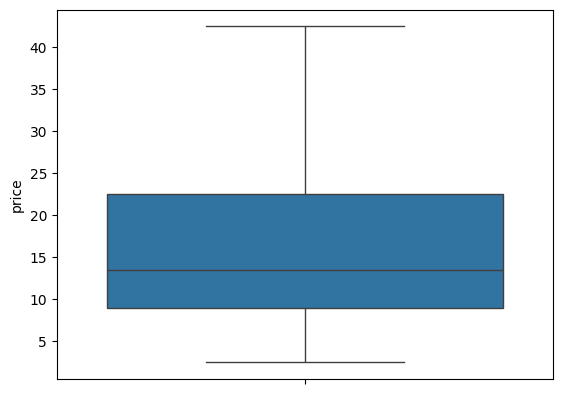

In [259]:
sns.boxplot(regular_df_price["price"])

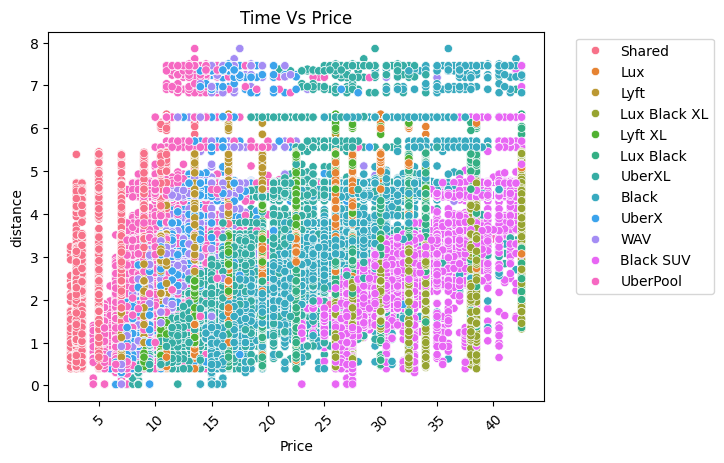

In [265]:
sns.scatterplot(data=regular_df_price, x="price", y="distance", hue="name")
plt.title("Time Vs Price")
# plt.colorbar(label="Distance") # Colorbar is not suitable when hue is categorical
plt.xlabel("Price")
plt.xticks(rotation=45)
plt.ylabel("distance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.show()


#REMOVING DISTANCE OUTLIERS


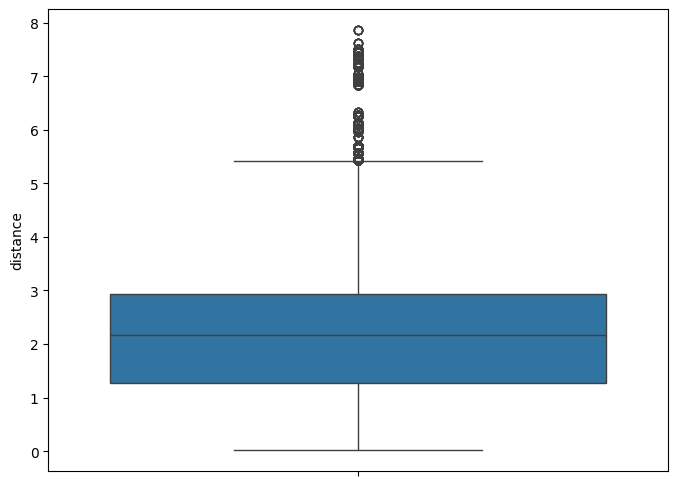

Total: 637976, Outliers: 5589 (99.1%)


In [260]:
from matplotlib.cbook import boxplot_stats
# Your boxplot (replace 'price' with your column)

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='distance')  # Or x='category', y='price'
plt.show()

# Extract outliers (matches boxplot exactly)
outlier_values = boxplot_stats(df['distance'])[0]['fliers']

# Create outlier DF (keep all columns)
outlier_df_distance = df[df['distance'].isin(outlier_values)].copy()
regular_df_distance = df[~df['distance'].isin(outlier_values)].copy()

print(f"Total: {len(df)}, Outliers: {len(outlier_df_distance)} ({len(regular_df_distance)/len(df)*100:.1f}%)")

<Axes: ylabel='price'>

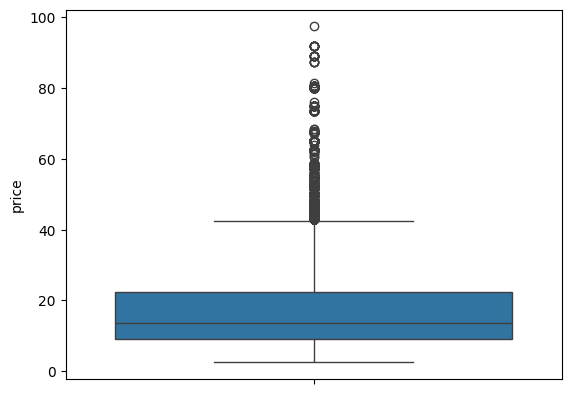

In [262]:
sns.boxplot(regular_df_distance["price"])

<Axes: ylabel='distance'>

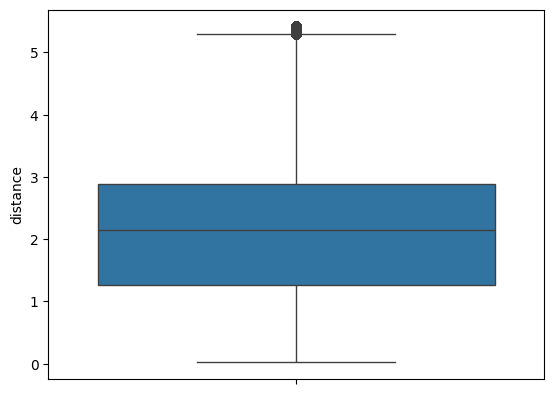

In [263]:
sns.boxplot(regular_df_distance["distance"])

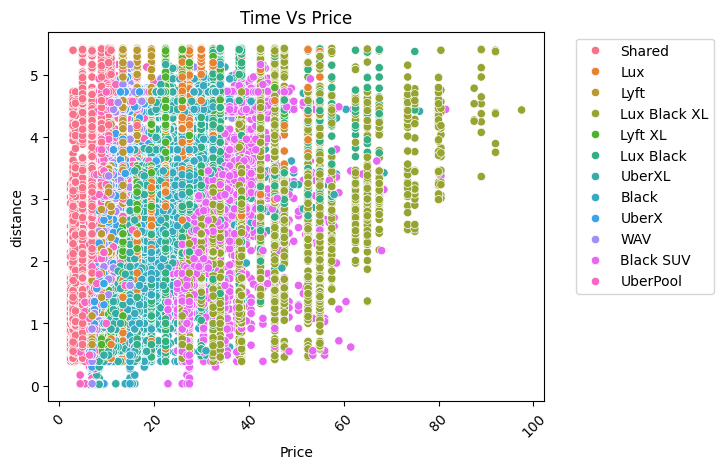

In [266]:
sns.scatterplot(data=regular_df_distance, x="price", y="distance", hue="name")
plt.title("Time Vs Price")
# plt.colorbar(label="Distance") # Colorbar is not suitable when hue is categorical
plt.xlabel("Price")
plt.xticks(rotation=45)
plt.ylabel("distance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.show()


#REMOINVG BOTH

Total: 637976, Outliers: 5589 (99.1%)


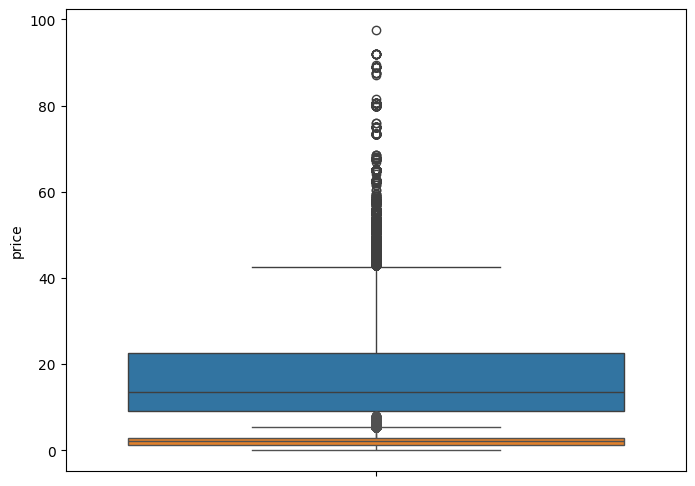

In [273]:
from matplotlib.cbook import boxplot_stats
# Your boxplot (replace 'price' with your column)

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='price')  # Or x='category', y='price'
# Extract outliers (matches boxplot exactly)
outlier_values = boxplot_stats(df['price'])[0]['fliers']

# Create outlier DF (keep all columns)
outlier_df_price = df[df['price'].isin(outlier_values)].copy()
regular_df_price = df[~df['price'].isin(outlier_values)].copy()
print(f"Total: {len(df)}, Outliers: {len(outlier_df_price)} ({len(regular_df_price)/len(df)*100:.1f}%)")

sns.boxplot(data=regular_df_price, y='distance')  # Or x='category', y='price'
distance_outlier_values = boxplot_stats(regular_df_price['distance'])[0]['fliers']
outlier_df_combine = regular_df_price[regular_df_price['distance'].isin(distance_outlier_values)].copy()
regular_df_combine = regular_df_price[~regular_df_price['distance'].isin(distance_outlier_values)].copy()

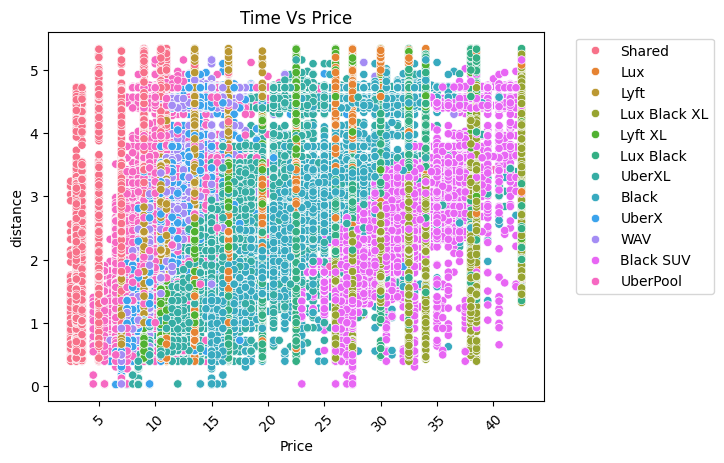

In [274]:
sns.scatterplot(data=regular_df_combine, x="price", y="distance", hue="name")
plt.title("Time Vs Price")
# plt.colorbar(label="Distance") # Colorbar is not suitable when hue is categorical
plt.xlabel("Price")
plt.xticks(rotation=45)
plt.ylabel("distance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.show()

In [275]:
outlier_df_combine

,distance,cab_type,price,surge_multiplier,product_id,name,Formated_Address_Destination,Formated_Address_Source,LatLong_Destination,LatLong_Source,Fixed_TimeStamps,hour
516,7.46,Uber,16.0,1.0,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV,"360 Huntington Ave, Boston, MA 02115, USA","Financial District, Boston, MA, USA","(42.3398067, -71.0891717)","(42.3559219, -71.05497679999999)",2018-12-14 20:15:05.605999947,20
1977,5.56,Uber,12.5,1.0,997acbb5-e102-41e1-b155-9df7de0a73f2,UberPool,"Commonwealth Ave, Boston, MA 02215, USA","Financial District, Boston, MA, USA","(42.3504997, -71.1053991)","(42.3559219, -71.05497679999999)",2018-12-16 23:50:09.246999979,23
1978,5.56,Uber,15.0,1.0,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV,"Commonwealth Ave, Boston, MA 02215, USA","Financial District, Boston, MA, USA","(42.3504997, -71.1053991)","(42.3559219, -71.05497679999999)",2018-12-17 03:30:08.176000118,3
1979,5.56,Uber,15.0,1.0,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX,"Commonwealth Ave, Boston, MA 02215, USA","Financial District, Boston, MA, USA","(42.3504997, -71.1053991)","(42.3559219, -71.05497679999999)",2018-12-16 16:50:06.963999987,16
1980,5.56,Uber,33.5,1.0,6c84fd89-3f11-4782-9b50-97c468b19529,Black,"Commonwealth Ave, Boston, MA 02215, USA","Financial District, Boston, MA, USA","(42.3504997, -71.1053991)","(42.3559219, -71.05497679999999)",2018-12-17 11:15:10.723000050,11
...,...,...,...,...,...,...,...,...,...,...,...,...
693004,7.36,Uber,16.0,1.0,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV,"North End, Boston, MA, USA","Back Bay, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3495236, -71.0794717)",2018-11-30 05:23:02.308000088,5
693005,7.36,Uber,14.5,1.0,997acbb5-e102-41e1-b155-9df7de0a73f2,UberPool,"North End, Boston, MA, USA","Back Bay, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3495236, -71.0794717)",2018-11-30 05:23:02.308000088,5
693006,7.36,Uber,36.0,1.0,6c84fd89-3f11-4782-9b50-97c468b19529,Black,"North End, Boston, MA, USA","Back Bay, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3495236, -71.0794717)",2018-12-13 18:15:03.572999954,18
693008,7.36,Uber,16.0,1.0,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX,"North End, Boston, MA, USA","Back Bay, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3495236, -71.0794717)",2018-12-13 18:15:03.572999954,18


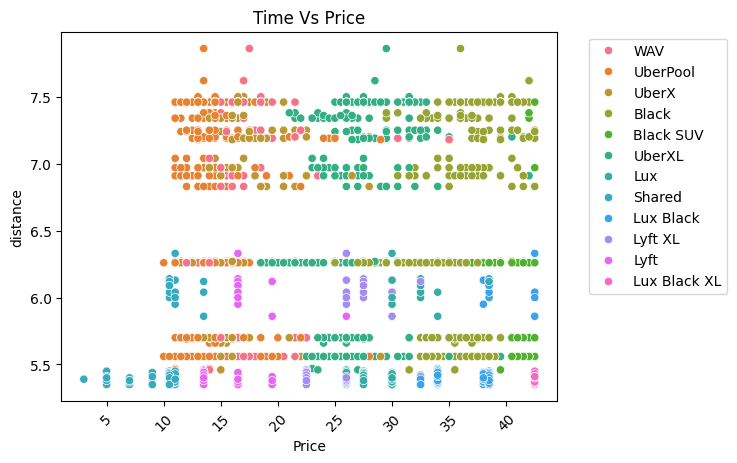

In [276]:
sns.scatterplot(data=outlier_df_combine, x="price", y="distance", hue="name")
plt.title("Time Vs Price")
# plt.colorbar(label="Distance") # Colorbar is not suitable when hue is categorical
plt.xlabel("Price")
plt.xticks(rotation=45)
plt.ylabel("distance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.show()

#UPDATES
- What I did now was apply removed Outliers for Distance , Price and both.

- The outliers marked are values where distance is above 5.5 miles.

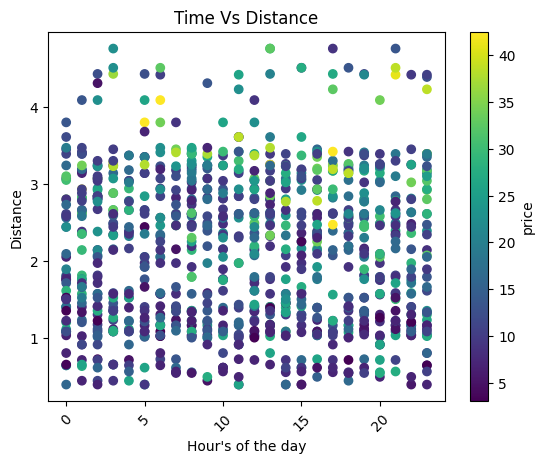

In [278]:
plt.scatter(regular_df_combine["hour"].iloc[:1000], regular_df_combine["distance"].iloc[:1000],c=regular_df_combine["price"].iloc[:1000])
plt.title("Time Vs Distance")
plt.colorbar(label="price")
plt.xlabel("Hour's of the day")
plt.xticks(rotation=45)
plt.ylabel("Distance")
plt.show()

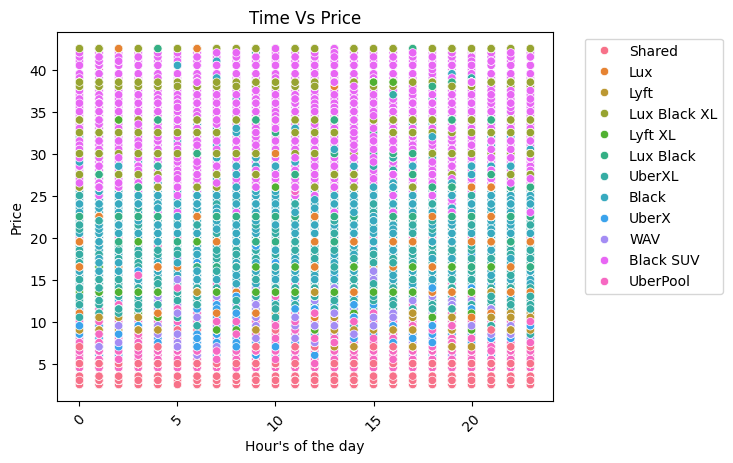

In [280]:
sns.scatterplot(data=regular_df_combine, x="hour", y="price", hue="name")
plt.title("Time Vs Price")
# plt.colorbar(label="Distance") # Colorbar is not suitable when hue is categorical
plt.xlabel("Hour's of the day")
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.show()

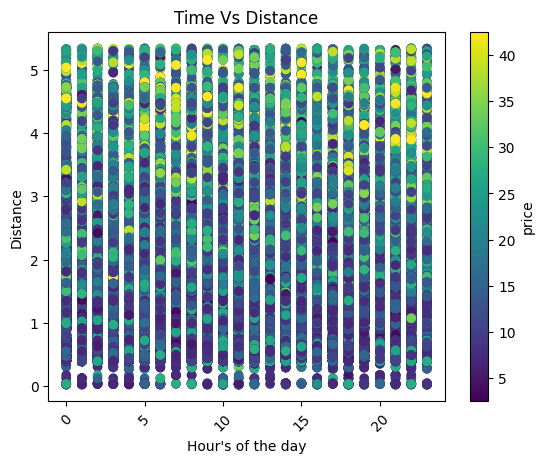

In [281]:
plt.scatter(regular_df_combine["hour"], regular_df_combine["distance"],c=regular_df_combine["price"])
plt.title("Time Vs Distance")
plt.colorbar(label="price")
plt.xlabel("Hour's of the day")
plt.xticks(rotation=45)
plt.ylabel("Distance")
plt.show()

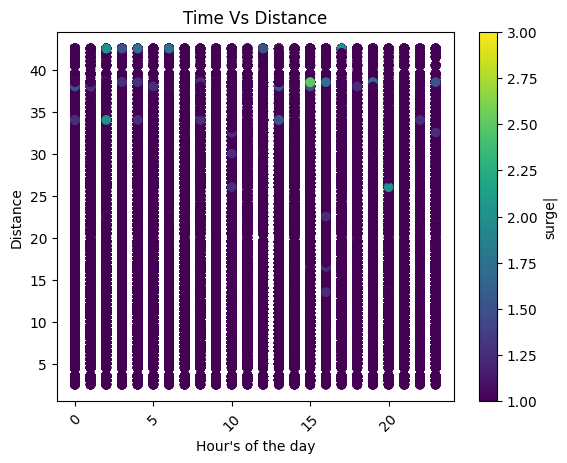

In [287]:
plt.scatter(regular_df_combine["hour"], regular_df_combine["price"],c=regular_df_combine["surge_multiplier"])
plt.title("Time Vs Distance")
plt.colorbar(label="surge|")
plt.xlabel("Hour's of the day")
plt.xticks(rotation=45)
plt.ylabel("Distance")
plt.show()

#My understanding:
Shared/UberPool (light pink) form the lowest price band, roughly from a few dollars up into the teens.
​

Standard services (Lyft, UberX, maybe WAV) sit in a middle band, generally higher than Shared but below premium options.
​

Premium/Lux categories (Lux, Lux Black, Black, Black SUV, UberXL, Lyft XL) occupy the upper price bands, often from high teens up into 30–40+.
​

Bands are relatively parallel, suggesting a consistent price ordering between categories across the day.


Shared/UberPool (pink) cluster at the lowest prices, mostly between about 3–15, across almost all distances.
​

UberX / Lyft–type standard rides (blue/green shades) occupy a middle price band, roughly 8–30, again spanning distances.
​

Premium / XL / Black / SUV (darker greens, oranges) are mostly in the high price range 20–40+, with fewer very cheap points.



X-axis: hour 0–23, y-axis: distance (roughly 3–42+ units).
​

Colorbar shows surge from 1.0 to 3.0; almost every point is dark purple, meaning surge ≈ 1.0 (no surge).
​

Only a handful of points (teal/green/yellow) reach surge >1.2–3.0, scattered at various hours and distances, with a few around mid‑day and evening.
​

#MACHINE LEARNING

In [290]:
regular_df_combine.to_csv("regular_df_combine.csv", index=False)

In [366]:
df = pd.read_csv("regular_df_combine.csv")
df

,distance,cab_type,price,surge_multiplier,product_id,name,Formated_Address_Destination,Formated_Address_Source,LatLong_Destination,LatLong_Source,Fixed_TimeStamps,hour
0,0.44,Lyft,5.0,1.0,lyft_line,Shared,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-12-16 09:30:07.890000105,9
1,0.44,Lyft,11.0,1.0,lyft_premier,Lux,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-27 02:00:23.677000046,2
2,0.44,Lyft,7.0,1.0,lyft,Lyft,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-28 01:00:22.197999954,1
3,0.44,Lyft,26.0,1.0,lyft_luxsuv,Lux Black XL,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-30 04:53:02.749000072,4
4,0.44,Lyft,9.0,1.0,lyft_plus,Lyft XL,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-29 03:49:20.223000050,3
...,...,...,...,...,...,...,...,...,...,...,...,...
625224,1.00,Uber,9.5,1.0,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV,"North End, Boston, MA, USA","West End, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3651729, -71.0641373)",2018-12-01 23:53:05.533999919,23
625225,1.00,Uber,13.0,1.0,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,"North End, Boston, MA, USA","West End, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3651729, -71.0641373)",2018-12-01 23:53:05.533999919,23
625226,1.00,Uber,9.5,1.0,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX,"North End, Boston, MA, USA","West End, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3651729, -71.0641373)",2018-12-01 23:53:05.533999919,23
625227,1.00,Uber,27.0,1.0,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV,"North End, Boston, MA, USA","West End, Boston, MA, USA","(42.3652089, -71.0554946)","(42.3651729, -71.0641373)",2018-12-01 23:53:05.533999919,23


In [330]:
df['name'].unique()


array(['Shared', 'Lux', 'Lyft', 'Lux Black XL', 'Lyft XL', 'Lux Black',
       'UberXL', 'Black', 'UberX', 'WAV', 'Black SUV', 'UberPool'],
      dtype=object)

In [396]:
## Label Encoding for Cab_Type
## OHE for service_type
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
label_encoder = LabelEncoder()

df_encoded = pd.get_dummies(df, columns=["cab_type"], prefix="cab_type")
df_encoded.head()


,distance,price,surge_multiplier,product_id,name,Formated_Address_Destination,Formated_Address_Source,LatLong_Destination,LatLong_Source,Fixed_TimeStamps,hour,cab_type_Lyft,cab_type_Uber
0,0.44,5.0,1.0,lyft_line,Shared,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-12-16 09:30:07.890000105,9,True,False
1,0.44,11.0,1.0,lyft_premier,Lux,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-27 02:00:23.677000046,2,True,False
2,0.44,7.0,1.0,lyft,Lyft,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-28 01:00:22.197999954,1,True,False
3,0.44,26.0,1.0,lyft_luxsuv,Lux Black XL,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-30 04:53:02.749000072,4,True,False
4,0.44,9.0,1.0,lyft_plus,Lyft XL,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-29 03:49:20.223000050,3,True,False


In [397]:
df_encoded2 = pd.get_dummies(df_encoded, columns=["name"], prefix="name")
df_encoded2.head()

,distance,price,surge_multiplier,product_id,Formated_Address_Destination,Formated_Address_Source,LatLong_Destination,LatLong_Source,Fixed_TimeStamps,hour,...,name_Lux,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_UberPool,name_UberX,name_UberXL,name_WAV
0,0.44,5.0,1.0,lyft_line,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-12-16 09:30:07.890000105,9,...,False,False,False,False,False,True,False,False,False,False
1,0.44,11.0,1.0,lyft_premier,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-27 02:00:23.677000046,2,...,True,False,False,False,False,False,False,False,False,False
2,0.44,7.0,1.0,lyft,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-28 01:00:22.197999954,1,...,False,False,False,True,False,False,False,False,False,False
3,0.44,26.0,1.0,lyft_luxsuv,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-30 04:53:02.749000072,4,...,False,False,True,False,False,False,False,False,False,False
4,0.44,9.0,1.0,lyft_plus,"North Station, 135 Causeway St, Boston, MA 021...","1686 Boston Rd, Springfield, MA 01129, USA","(42.3662621, -71.06111369999999)","(42.1450532, -72.48697229999999)",2018-11-29 03:49:20.223000050,3,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
# from sklearn.preprocessing import OrdinalEncoder
# import pandas as pd


# surge_order = [[1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]]

# ord_enc = OrdinalEncoder(categories=surge_order)
# df['surge_encoded'] = ord_enc.fit_transform(df[['surge_multiplier']])

# print(df[['surge_multiplier', 'surge_encoded']].head())


In [ ]:
# ohe = OneHotEncoder(sparse_output=False)
# df["cab_type_encoded"] = label_encoder.fit_transform(df["cab_type"])
# service_encoded = ohe.fit_transform(df[['name']])
# service_encoded_df = pd.DataFrame(service_encoded, columns=ohe.get_feature_names_out(['name']))
# df_final = pd.concat([df.drop('name', axis=1), service_encoded_df], axis=1)
# print(df_final.head())

In [398]:
df_encoded.columns

Index(['distance', 'price', 'surge_multiplier', 'product_id', 'name',
       'Formated_Address_Destination', 'Formated_Address_Source',
       'LatLong_Destination', 'LatLong_Source', 'Fixed_TimeStamps', 'hour',
       'cab_type_Lyft', 'cab_type_Uber'],
      dtype='object')

In [399]:
df_encoded2.columns

Index(['distance', 'price', 'surge_multiplier', 'product_id',
       'Formated_Address_Destination', 'Formated_Address_Source',
       'LatLong_Destination', 'LatLong_Source', 'Fixed_TimeStamps', 'hour',
       'cab_type_Lyft', 'cab_type_Uber', 'name_Black', 'name_Black SUV',
       'name_Lux', 'name_Lux Black', 'name_Lux Black XL', 'name_Lyft',
       'name_Lyft XL', 'name_Shared', 'name_UberPool', 'name_UberX',
       'name_UberXL', 'name_WAV'],
      dtype='object')

In [400]:
df_encoded = df_encoded.drop(["Formated_Address_Destination","Formated_Address_Source","LatLong_Destination","LatLong_Source","Fixed_TimeStamps","product_id", "Fixed_TimeStamps","name"], axis=1)
df_encoded2 = df_encoded2.drop(["Formated_Address_Destination","Formated_Address_Source","LatLong_Destination","LatLong_Source","Fixed_TimeStamps","product_id", "Fixed_TimeStamps"], axis=1)

In [346]:
df_encoded

,distance,price,surge_multiplier,hour,cab_type_Lyft,cab_type_Uber
0,0.44,5.0,1.0,9,True,False
1,0.44,11.0,1.0,2,True,False
2,0.44,7.0,1.0,1,True,False
3,0.44,26.0,1.0,4,True,False
4,0.44,9.0,1.0,3,True,False
...,...,...,...,...,...,...
625224,1.00,9.5,1.0,23,False,True
625225,1.00,13.0,1.0,23,False,True
625226,1.00,9.5,1.0,23,False,True
625227,1.00,27.0,1.0,23,False,True


In [401]:
df_encoded2

,distance,price,surge_multiplier,hour,cab_type_Lyft,cab_type_Uber,name_Black,name_Black SUV,name_Lux,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_UberPool,name_UberX,name_UberXL,name_WAV
0,0.44,5.0,1.0,9,True,False,False,False,False,False,False,False,False,True,False,False,False,False
1,0.44,11.0,1.0,2,True,False,False,False,True,False,False,False,False,False,False,False,False,False
2,0.44,7.0,1.0,1,True,False,False,False,False,False,False,True,False,False,False,False,False,False
3,0.44,26.0,1.0,4,True,False,False,False,False,False,True,False,False,False,False,False,False,False
4,0.44,9.0,1.0,3,True,False,False,False,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625224,1.00,9.5,1.0,23,False,True,False,False,False,False,False,False,False,False,False,False,False,True
625225,1.00,13.0,1.0,23,False,True,False,False,False,False,False,False,False,False,False,False,True,False
625226,1.00,9.5,1.0,23,False,True,False,False,False,False,False,False,False,False,False,True,False,False
625227,1.00,27.0,1.0,23,False,True,False,True,False,False,False,False,False,False,False,False,False,False


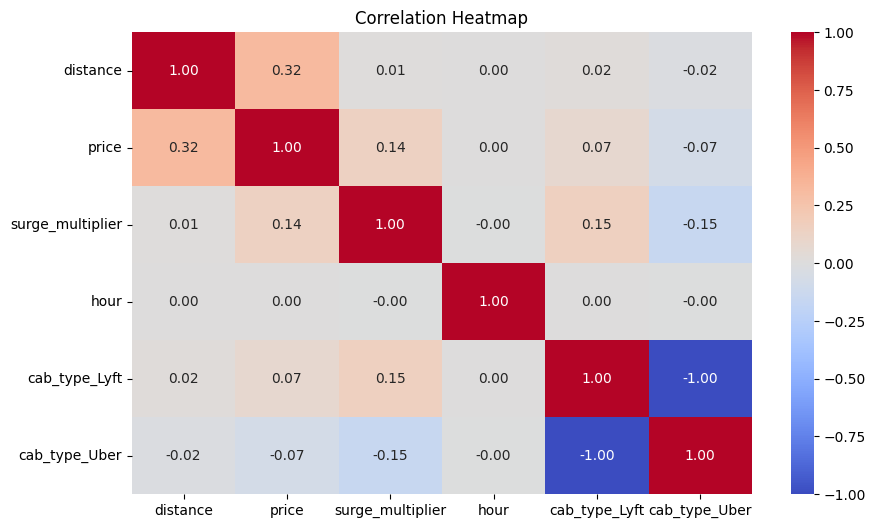

In [370]:
# Correlation matrix
corr = df_encoded.corr(numeric_only=True)

# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

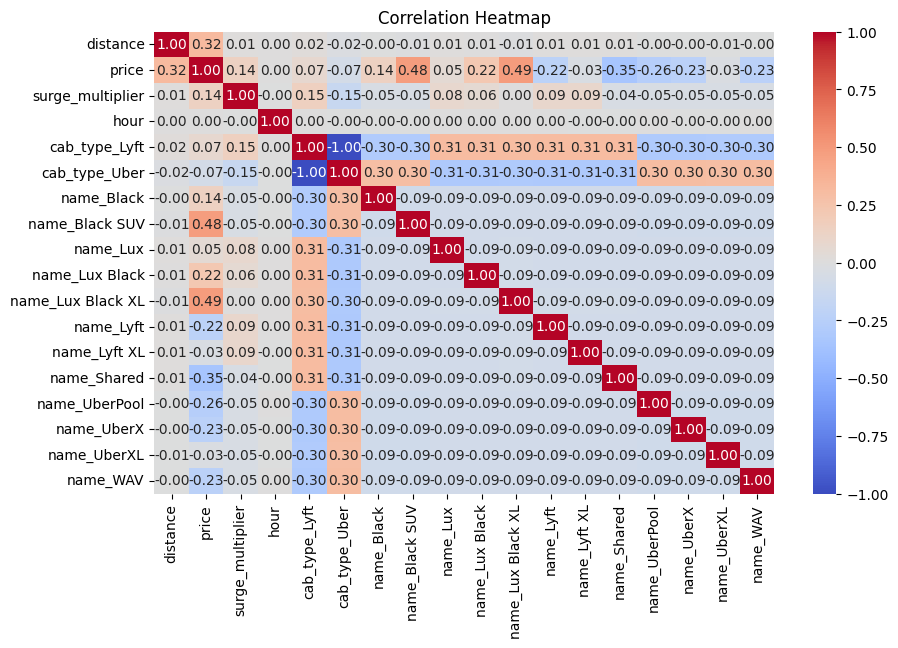

In [402]:
# Correlation matrix
corr = df_encoded2.corr(numeric_only=True)

# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [371]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
# Assuming df_final is your fully preprocessed dataframe
X = df_encoded.drop(columns=['price'], axis=1) ### Doing this because we have 2 surges, one is encoded and one is multiplier
#X = df.drop('price', axis=1) --- IGNORE ---
y = df_encoded['price']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.columns

Index(['distance', 'surge_multiplier', 'hour', 'cab_type_Lyft',
       'cab_type_Uber'],
      dtype='object')

In [372]:
import joblib
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

print("Linear Regression:")
print("R2 Score:", r2_score(y_test, y_pred_lin))
print("MSE:", mean_squared_error(y_test, y_pred_lin))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print("MAE:", mean_absolute_error(y_test, y_pred_lin))



# Save model
# joblib.dump(lin_reg, "./models/linear_reg.pkl")




Linear Regression:
R2 Score: 0.12139697485324374
MSE: 66.88267350131605
RMSE: 8.178182775000572
MAE: 6.735225207532479


In [373]:
ridge_reg = Ridge(alpha=1.0)  # alpha is regularization strength
ridge_reg.fit(X_train, y_train)

y_pred_ridge = ridge_reg.predict(X_test)

print("\nRidge Regression:")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))

# joblib.dump(lin_reg, "./models/ridge.pkl")




Ridge Regression:
R2 Score: 0.12139714653693223
MSE: 66.8826604320871
RMSE: 8.1781819759704
MAE: 6.7352295537324105


In [374]:
lasso_reg = Lasso(alpha=0.1)  # alpha is regularization strength
lasso_reg.fit(X_train, y_train)

y_pred_lasso = lasso_reg.predict(X_test)

print("\nLasso Regression:")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))

# joblib.dump(lin_reg, "./models/lasso.pkl")




Lasso Regression:
R2 Score: 0.10367888284435645
MSE: 68.23144345655123
RMSE: 8.260232651478482
MAE: 6.820326278578291


In [375]:
from sklearn.ensemble import RandomForestRegressor
# Initialize model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Fit model
rf_reg.fit(X_train, y_train)

# Predict
y_pred_rf = rf_reg.predict(X_test)

# Evaluate
print("Random Forest Regression:")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

# joblib.dump(lin_reg, "./models/randomforest.pkl")



Random Forest Regression:
R2 Score: 0.06883913723964452
MSE: 70.88358015931257
RMSE: 8.419238692382617
MAE: 6.913671026641599


In [376]:
import xgboost as xgb

xgb_reg = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_train)

y_pred_xgb = xgb_reg.predict(X_test)

print("\nXGBoost Regression:")
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))

# joblib.dump(lin_reg, "./models/xgboost.pkl")





XGBoost Regression:
R2 Score: 0.12454811844389246
MSE: 66.64279621669833
RMSE: 8.163503917846695
MAE: 6.721009666477404


In [ ]:
df_encoded2 = pd.get_dummies(df, columns=["cab_type"], prefix="cab_type")


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

feat_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_reg.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_importance['feature'], feat_importance['importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()


In [ ]:
xgb.plot_importance(xgb_reg, max_num_features=15, height=0.5)
plt.show()

In [415]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
# Assuming df_final is your fully preprocessed dataframe
X = df_encoded2.drop(columns=['price'], axis=1) ### Doing this because we have 2 surges, one is encoded and one is multiplier
#X = df.drop('price', axis=1) --- IGNORE ---
y = df_encoded2['price']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.columns

Index(['distance', 'surge_multiplier', 'hour', 'cab_type_Lyft',
       'cab_type_Uber', 'name_Black', 'name_Black SUV', 'name_Lux',
       'name_Lux Black', 'name_Lux Black XL', 'name_Lyft', 'name_Lyft XL',
       'name_Shared', 'name_UberPool', 'name_UberX', 'name_UberXL',
       'name_WAV'],
      dtype='object')

In [416]:
import joblib
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

print("Linear Regression:")
print("R2 Score:", r2_score(y_test, y_pred_lin))
print("MSE:", mean_squared_error(y_test, y_pred_lin))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print("MAE:", mean_absolute_error(y_test, y_pred_lin))



# Save model
# joblib.dump(lin_reg, "./models/linear_reg.pkl")




Linear Regression:
R2 Score: 0.9363345301567586
MSE: 4.846462749342512
RMSE: 2.201468316679237
MAE: 1.6466800759202125


In [417]:
ridge_reg = Ridge(alpha=1.0)  # alpha is regularization strength
ridge_reg.fit(X_train, y_train)

y_pred_ridge = ridge_reg.predict(X_test)

print("\nRidge Regression:")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))

# joblib.dump(lin_reg, "./models/ridge.pkl")




Ridge Regression:
R2 Score: 0.9363347002960971
MSE: 4.846449797675488
RMSE: 2.2014653750798554
MAE: 1.646670212935533


In [418]:
lasso_reg = Lasso(alpha=0.1)  # alpha is regularization strength
lasso_reg.fit(X_train, y_train)

y_pred_lasso = lasso_reg.predict(X_test)

print("\nLasso Regression:")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))

# joblib.dump(lin_reg, "./models/lasso.pkl")




Lasso Regression:
R2 Score: 0.9041511191428385
MSE: 7.296388949679845
RMSE: 2.70118287971767
MAE: 1.9007745856268943


In [419]:
from sklearn.ensemble import RandomForestRegressor
# Initialize model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Fit model
rf_reg.fit(X_train, y_train)

# Predict
y_pred_rf = rf_reg.predict(X_test)

# Evaluate
print("Random Forest Regression:")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

# joblib.dump(lin_reg, "./models/randomforest.pkl")



Random Forest Regression:
R2 Score: 0.9601954258517581
MSE: 3.030078727729293
RMSE: 1.7407121323554027
MAE: 1.1655776250506746


In [420]:
import xgboost as xgb

xgb_reg = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_train)

y_pred_xgb = xgb_reg.predict(X_test)

print("\nXGBoost Regression:")
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))

# joblib.dump(lin_reg, "./models/xgboost.pkl")





XGBoost Regression:
R2 Score: 0.9640514439169232
MSE: 2.736543661395395
RMSE: 1.6542501810171868
MAE: 1.1233372279195653


In [421]:
feature_cols = [
    'distance', 'surge_multiplier', 'hour',
    'cab_type_Lyft', 'cab_type_Uber',
    'name_Black','name_Black SUV','name_Lux','name_Lux Black',
    'name_Lux Black XL','name_Lyft','name_Lyft XL','name_Shared',
    'name_UberPool','name_UberX','name_UberXL','name_WAV'
]

In [422]:
import pandas as pd
import numpy as np

cab_types = ['Lyft', 'Uber']   # from cab_type_*
names = [
    'Black','Black SUV','Lux','Lux Black','Lux Black XL',
    'Lyft','Lyft XL','Shared','UberPool','UberX','UberXL','WAV'
]

def all_cab_prices(distance, dt, surge=1.0):
    dt = pd.to_datetime(dt)
    hour = dt.hour

    rows = []
    for cab in cab_types:
        for name in names:
            # base feature dict
            data = {col: 0 for col in feature_cols}
            data['distance'] = distance
            data['surge_multiplier'] = surge
            data['hour'] = hour

            # one‑hot cab_type
            cab_col = f'cab_type_{cab}'
            if cab_col in feature_cols:
                data[cab_col] = 1

            # one‑hot name
            name_col = f'name_{name}'
            if name_col in feature_cols:
                data[name_col] = 1

            rows.append({'cab_type': cab, 'name': name, **data})

    df_all = pd.DataFrame(rows)
    X = df_all[feature_cols]
    df_all['pred_price'] = xgb_reg.predict(X)
    return df_all[['cab_type','name','pred_price']].sort_values('pred_price')

In [423]:
results = all_cab_prices(
    distance=3.5,
    dt="2024-03-01 18:30:00",
    surge=1.0
)

print(results)


   cab_type          name  pred_price
7      Lyft        Shared    7.094652
19     Uber        Shared    7.123971
20     Uber      UberPool   10.633582
5      Lyft          Lyft   10.967358
17     Uber          Lyft   11.003518
21     Uber         UberX   11.488029
23     Uber           WAV   11.570533
8      Lyft      UberPool   13.133215
9      Lyft         UberX   14.090642
11     Lyft           WAV   14.147924
18     Uber       Lyft XL   16.529287
6      Lyft       Lyft XL   18.582468
22     Uber        UberXL   19.466295
14     Uber           Lux   19.620043
10     Lyft        UberXL   20.816816
2      Lyft           Lux   22.025177
15     Uber     Lux Black   25.521658
12     Uber         Black   25.723061
0      Lyft         Black   26.417418
3      Lyft     Lux Black   27.546738
16     Uber  Lux Black XL   34.838680
1      Lyft     Black SUV   35.663483
13     Uber     Black SUV   35.706352
4      Lyft  Lux Black XL   36.809025


#DEEP NEURAL NETWORK


In [424]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
n_features = X_train.shape[1]
print(n_features)

17


In [425]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)          # price (regression)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [426]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
15631/15631 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 12.1839 - mae: 1.8971 - val_loss: 3.3931 - val_mae: 1.2514
Epoch 2/10
15631/15631 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 3.1266 - mae: 1.2259 - val_loss: 3.0264 - val_mae: 1.1917
Epoch 3/10
15631/15631 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step - loss: 3.0834 - mae: 1.2142 - val_loss: 3.1820 - val_mae: 1.2084
Epoch 4/10
15631/15631 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 3.0625 - mae: 1.2073 - val_loss: 3.0421 - val_mae: 1.1899
Epoch 5/10
15631/15631 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 3.0672 - mae: 1.2029 - val_loss: 3.0348 - val_mae: 1.1857
Epoch 6/10
15631/15631 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 3.0453 - mae: 1.2025 - val_loss: 3.0547 - val_mae: 1.2501
Epoch 7/10
15631/15631 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 3.0117 - mae: 1.1965 - val_loss: 2.9701 - val_mae: 1.2075
Epoch 8/10
15631/15631 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 3.0234 - mae: 1.1951 - val_loss: 2.9879 - val_mae: 1.1769
Epoch 9/10
1563

In [427]:
cab_types = ['Lyft', 'Uber']
names = [
    'Black','Black SUV','Lux','Lux Black','Lux Black XL',
    'Lyft','Lyft XL','Shared','UberPool','UberX','UberXL','WAV'
]

def all_cab_prices_tf(distance, dt, surge=1.0):
    dt = pd.to_datetime(dt)
    hour = dt.hour

    rows = []
    feats = []
    for cab in cab_types:
        for name in names:
            data = {col: 0.0 for col in feature_cols}
            data['distance'] = float(distance)
            data['surge_multiplier'] = float(surge)
            data['hour'] = float(hour)

            cab_col = f'cab_type_{cab}'
            if cab_col in feature_cols:
                data[cab_col] = 1.0
            name_col = f'name_{name}'
            if name_col in feature_cols:
                data[name_col] = 1.0

            rows.append({'cab_type': cab, 'name': name})
            feats.append([data[c] for c in feature_cols])

    X_new = np.array(feats, dtype='float32')
    preds = model.predict(X_new, verbose=0).flatten()

    out = pd.DataFrame(rows)
    out['pred_price'] = preds
    return out.sort_values('pred_price')


In [429]:
results = all_cab_prices_tf(3.5, "2024-03-01 10:30:00", surge=1.0)
print(results)


   cab_type          name  pred_price
7      Lyft        Shared    7.637756
19     Uber        Shared    8.196919
8      Lyft      UberPool    9.917648
20     Uber      UberPool   10.290308
9      Lyft         UberX   11.219250
5      Lyft          Lyft   11.616968
21     Uber         UberX   11.739554
17     Uber          Lyft   11.801302
23     Uber           WAV   12.081299
11     Lyft           WAV   12.242722
6      Lyft       Lyft XL   18.881113
18     Uber       Lyft XL   18.968027
10     Lyft        UberXL   19.158640
22     Uber        UberXL   19.715063
2      Lyft           Lux   22.358007
14     Uber           Lux   22.493593
12     Uber         Black   25.900557
0      Lyft         Black   26.045439
3      Lyft     Lux Black   27.918423
15     Uber     Lux Black   28.661966
13     Uber     Black SUV   35.080196
1      Lyft     Black SUV   35.568867
4      Lyft  Lux Black XL   36.772991
16     Uber  Lux Black XL   36.960892
